In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)




In [2]:
# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 2  # Gpc
qS = 0.5
phiS = 1.0
qK =  2.67 #ori : 1.0
phiK = phiS + np.pi/3
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5


params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [3]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    print(R,S)
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [4]:
theta, phi = get_viewing_angles(qS, phiS, 2.67, phiK)
theta, phi

[0.25903472 0.40342268 0.87758256] [-0.20833736  0.40371919 -0.89084587]


(0.8326904833428617, -1.5707963267948966)

In [5]:
theta*180/np.pi  

47.709650336254555

In [6]:
print("Generating waveform...")
h = waveform_gen(*params, T=T, dt=dt)

Generating waveform...


In [7]:
h

array([-1.19444410e-22+1.36503982e-22j, -1.01633328e-22+1.49908725e-22j,
       -8.30424520e-23+1.60749046e-22j, ...,
       -1.96723357e-22-1.06425996e-22j, -2.13534893e-22-6.37767402e-23j,
       -2.21774037e-22-1.66139121e-23j])

In [8]:
h_real = h.real
h_real

array([-1.19444410e-22, -1.01633328e-22, -8.30424520e-23, ...,
       -1.96723357e-22, -2.13534893e-22, -2.21774037e-22])

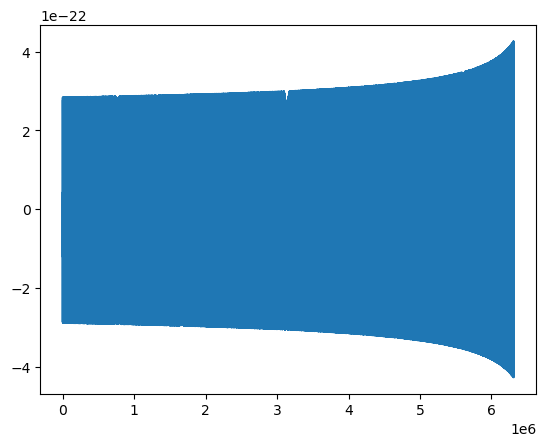

In [9]:
plt.plot(h_real.get())
plt.show()

In [10]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)
gwf.rhostat(h)

array(32.54153962)

In [ ]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [12]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [13]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


11.606899362022393

In [14]:
p_arr, e_arr

(array([11.7       , 11.69999959, 11.69999917, ...,  5.62159697,
         5.62159237,  5.62158778]),
 array([0.4       , 0.39999998, 0.39999996, ..., 0.12687824, 0.12687808,
        0.12687792]))

In [15]:
len(p_arr)

6311629

In [16]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.01971368776220821, 0.019108341687235263, 0.015451845941009939],
 [0.019713689337112185, 0.019108343183883658, 0.01545184703159573],
 [0.019713690912014286, 0.019108344680520625, 0.015451848122172113],
 [0.019713692486921473, 0.019108346177170728, 0.015451849212759373],
 [0.019713694061824667, 0.01910834767382069, 0.015451850303346351],
 [0.019713695636715104, 0.01910834917045682, 0.01545185139392199],
 [0.01971369721163589, 0.019108350667113083, 0.015451852484513974],
 [0.019713698786543627, 0.019108352163756902, 0.015451853575095858],
 [0.019713700361440087, 0.01910835366039379, 0.01545185466567214],
 [0.01971370193633806, 0.019108355157038372, 0.015451855756254467],
 [0.01971370351124129, 0.019108356653691774, 0.015451856846843819],
 [0.019713705086149946, 0.019108358150337634, 0.015451857937427298],
 [0.01971370666105235, 0.01910835964698086, 0.015451859028008398],
 [0.01971370823597391, 0.01910836114363829, 0.015451860118600969],
 [0.019713709810886857, 0.019108362640287625, 0.

In [17]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [18]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-1,6)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [19]:
modes_21 = [
    (2, m, 1) 
    for m in range(-2,3)
]
modes_21

[(2, -2, 1), (2, -1, 1), (2, 0, 1), (2, 1, 1), (2, 2, 1)]

In [20]:
len(modes), len(mode_freqs)

(84, 84)

In [21]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1,6)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-1,6)
]

mode_freqs_l2 = []
for l, m, n in modes_l2:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l2.append(f_mode)

mode_freqs_l3 = []
for l, m, n in modes_l3:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_l3.append(f_mode)

In [22]:
mode_freqs_21 = []
for l, m, n in modes_21:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs_21.append(f_mode)

In [23]:
mode_freqs_21

[array([-0.00077469, -0.00077469, -0.00077469, ..., -0.00328799,
        -0.00328799, -0.003288  ]),
 array([-0.00013771, -0.00013771, -0.00013771, ..., -0.00101654,
        -0.00101655, -0.00101655]),
 array([0.00049927, 0.00049927, 0.00049927, ..., 0.0012549 , 0.0012549 ,
        0.0012549 ]),
 array([0.00113625, 0.00113625, 0.00113625, ..., 0.00352634, 0.00352635,
        0.00352635]),
 array([0.00177323, 0.00177323, 0.00177323, ..., 0.00579779, 0.0057978 ,
        0.0057978 ])]

In [24]:
sum_freqs = np.zeros(6311629,)
for i in range(-2,3):
    print(i)
    sum_freqs += mode_freqs_21[i]

-2
-1
0
1
2


In [25]:
sum_freqs

array([0.00249636, 0.00249636, 0.00249636, ..., 0.0062745 , 0.0062745 ,
       0.00627451])

In [26]:
5*freq_r

array([0.00249636, 0.00249636, 0.00249636, ..., 0.0062745 , 0.0062745 ,
       0.00627451])

In [44]:
import scipy 
fs = 1.0 / dt  # Sampling frequency
nperseg = 2**16  # Window size for STFT
noverlap = nperseg * 3 // 4

f, t, Zxx = signal.stft(h_real.get(), fs=fs, 
                               nperseg=nperseg, noverlap=noverlap, 
                               return_onesided=False)

Zxx = scipy.fft.fftshift(Zxx, axes=0)
f = scipy.fft.fftshift(f)
# f = f - fs  # Shift to range [-fs, 0] or adjust as needed

t_years = t / YRSID_SI
T_total = len(h_real) * dt / YRSID_SI
t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

t_traj_years = t_arr - t_arr[-1] 

log_amp = np.log10(np.abs(Zxx))
max_val = np.max(log_amp)
# NOTE: change ord of magnitude
vmin_val = max_val - 6
t_spec_seconds = t - t[-1] 

extent = [t_spec_seconds[0], t_spec_seconds[-1], f[0], f[-1]]

In [45]:
log_amp

array([[-26.70889317, -27.00994263, -36.77072556, ..., -26.95873458,
        -26.48142348, -26.6359835 ],
       [-26.70889317, -27.00994263, -36.9886735 , ..., -26.95873459,
        -26.48142348, -26.6359835 ],
       [-26.70889317, -27.00994262, -36.80860623, ..., -26.95873458,
        -26.48142348, -26.63598349],
       ...,
       [-26.70889317, -27.00994262, -36.71521224, ..., -26.95873459,
        -26.48142348, -26.63598349],
       [-26.70889317, -27.00994262, -36.80860623, ..., -26.95873458,
        -26.48142348, -26.63598349],
       [-26.70889317, -27.00994263, -36.9886735 , ..., -26.95873459,
        -26.48142348, -26.6359835 ]])

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/2136346949.py:11: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")


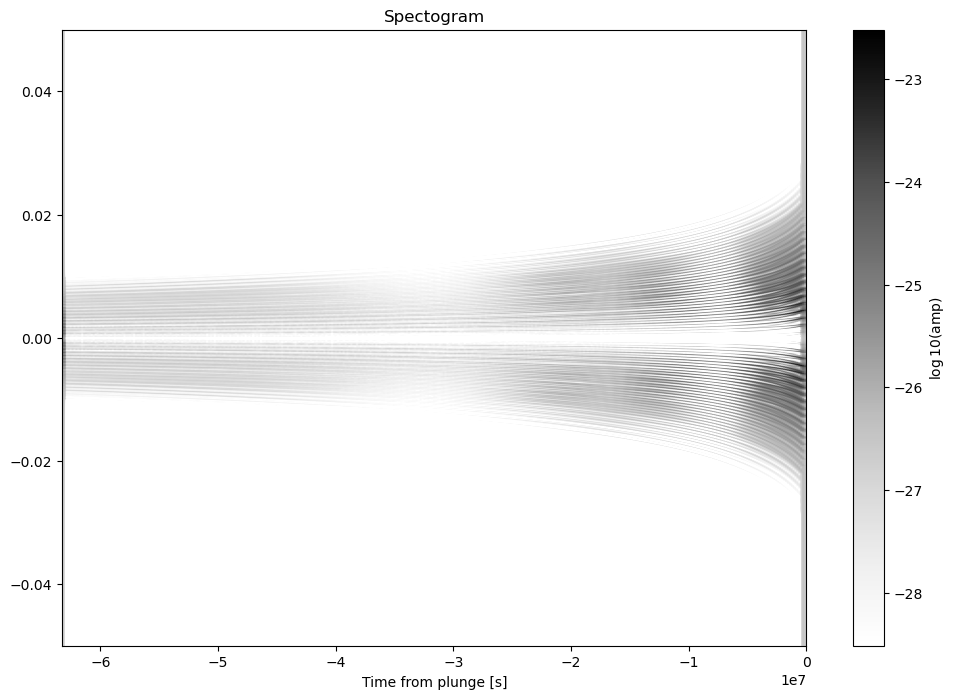

In [46]:
# STFT amplitudes only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)
cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")
plt.xlabel('Time from plunge [s]')
plt.title('Spectogram')
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3082237297.py:11: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")


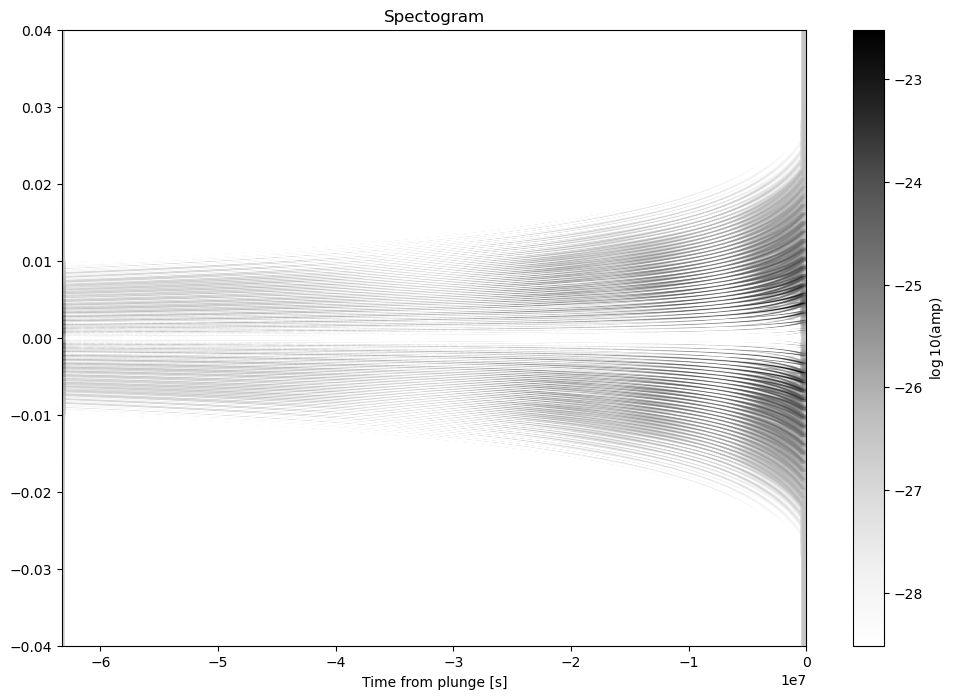

In [80]:
# STFT amplitudes only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)
cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")
plt.ylim(-0.04,0.04)
plt.xlabel('Time from plunge [s]')
plt.title('Spectogram')
plt.show()

In [47]:
from collections import defaultdict

# sum frequencies for each (l, n)
mode_groups = defaultdict(list)
for i, (ell, m, n) in enumerate(modes):
    mode_groups[(ell, n)].append(mode_freqs[i])
summed_freqs = {}
for (ell, n), freq_list in mode_groups.items():
    summed_freqs[(ell, n)] = np.sum(freq_list, axis=0)


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/832914784.py:44: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/832914784.py:48: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/832914784.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


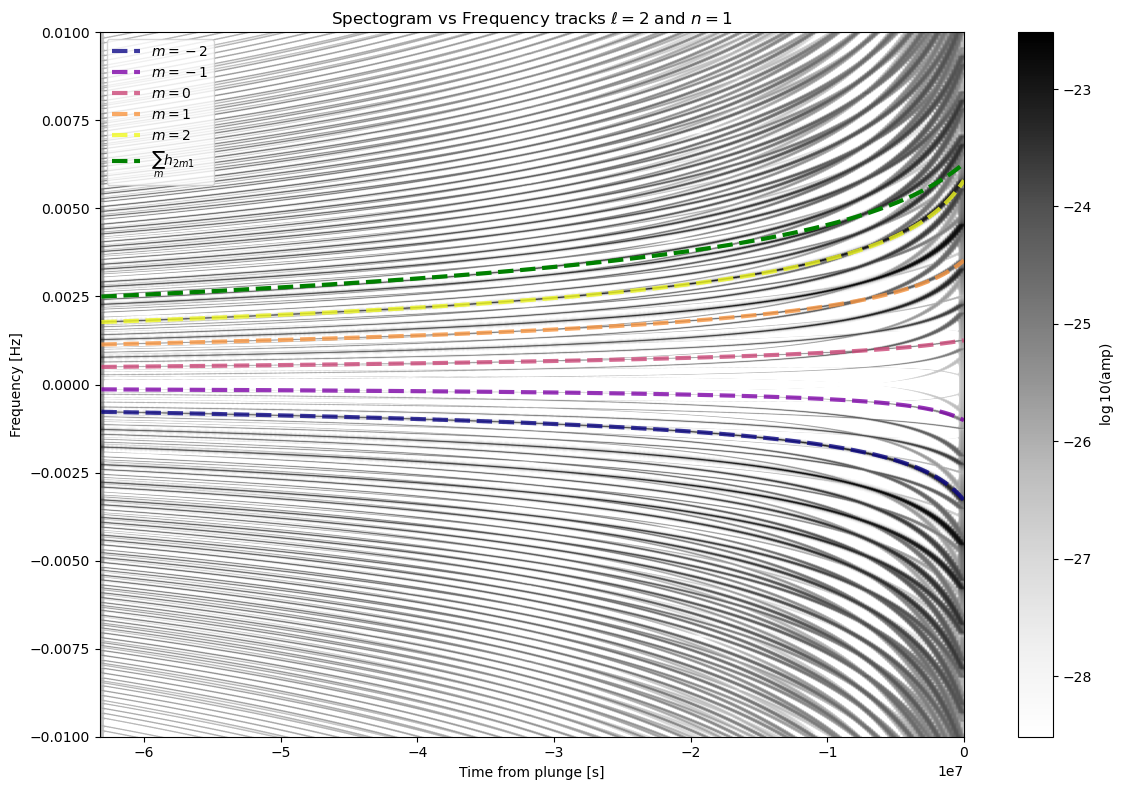

In [70]:
import matplotlib.cm as cm

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)

m_values = np.arange(-2, 3) 
cmap = cm.get_cmap('plasma') 
colors = cmap(np.linspace(0, 1, len(m_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$m={m}$'
    if ell == 2 and n == 1:
        color_idx = m + 2  # Map m to color index
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)


# # plot each m for (ell=2,n=1)
# for i in range(len(modes)):
#     ell, m, n = modes[i]
#     col = 'red'
#     lstyle = 'dashed'
#     linewidth=3
#     label = f'$m={m}$'
#     if ell==2 and n==1:
#         plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=col,linewidth=linewidth, alpha=0.8, label=label)
# plot summed freqs for (ell=2, n=1)
# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = r'$\sum_m h_{2m1}$'
    if ell == 2 and n==1:
        plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time from plunge [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
plt.ylim(-0.01,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/662304582.py:36: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/662304582.py:40: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=2$')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/662304582.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter')


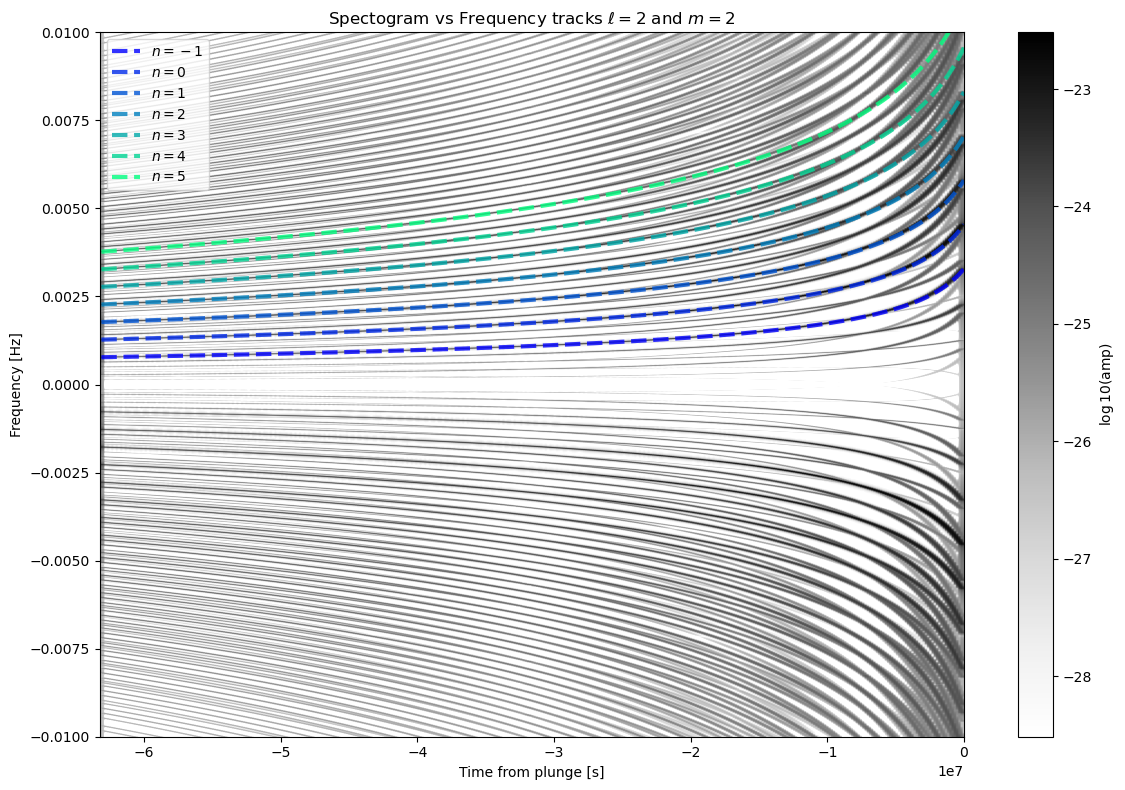

In [65]:

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# NOTE: plot each n for (ell=2,m=2)
n_values = np.arange(-1, 6) 
cmap = cm.get_cmap('winter') 
colors = cmap(np.linspace(0, 1, len(n_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$n={n}$'
    if ell == 2 and m == 2:
        color_idx = n + 1  
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)

# plot summed freqs for (ell=2, n=1)
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2 and n==1:
#         plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time from plunge [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $m=2$')
plt.ylim(-0.01,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/324998036.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/324998036.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/324998036.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('summer')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/324998036.py:43: UserWarning: Creating legend with loc="best" can be s

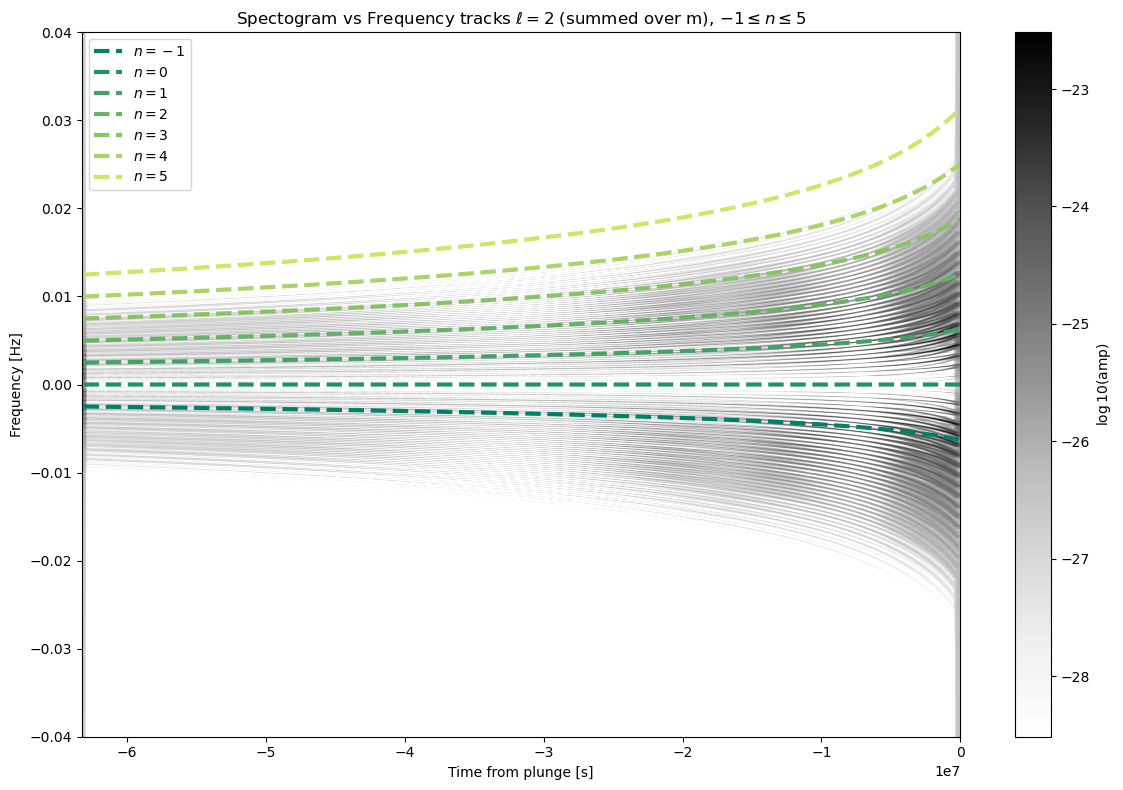

In [78]:

# Spectogram only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# plot summed freqs

n_values_summed = list(set(n for (ell, n) in summed_freqs.keys()))  
n_values_summed.sort()
cmap = cm.get_cmap('summer') 
colors_summed = cmap(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 2:
        color_idx = n_values_summed.index(n)
        plt.plot(t_traj_years, freq, color=colors_summed[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2:
#         plt.plot(t_traj_years, freq, color='red', linewidth=1, linestyle='dashed', alpha=1, label=label)


cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time from plunge [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
# plt.ylim(None,0.04)
plt.ylim(-0.04, 0.04)

plt.legend()
plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3758540502.py:34: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3758540502.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3758540502.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('autumn')


/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3758540502.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


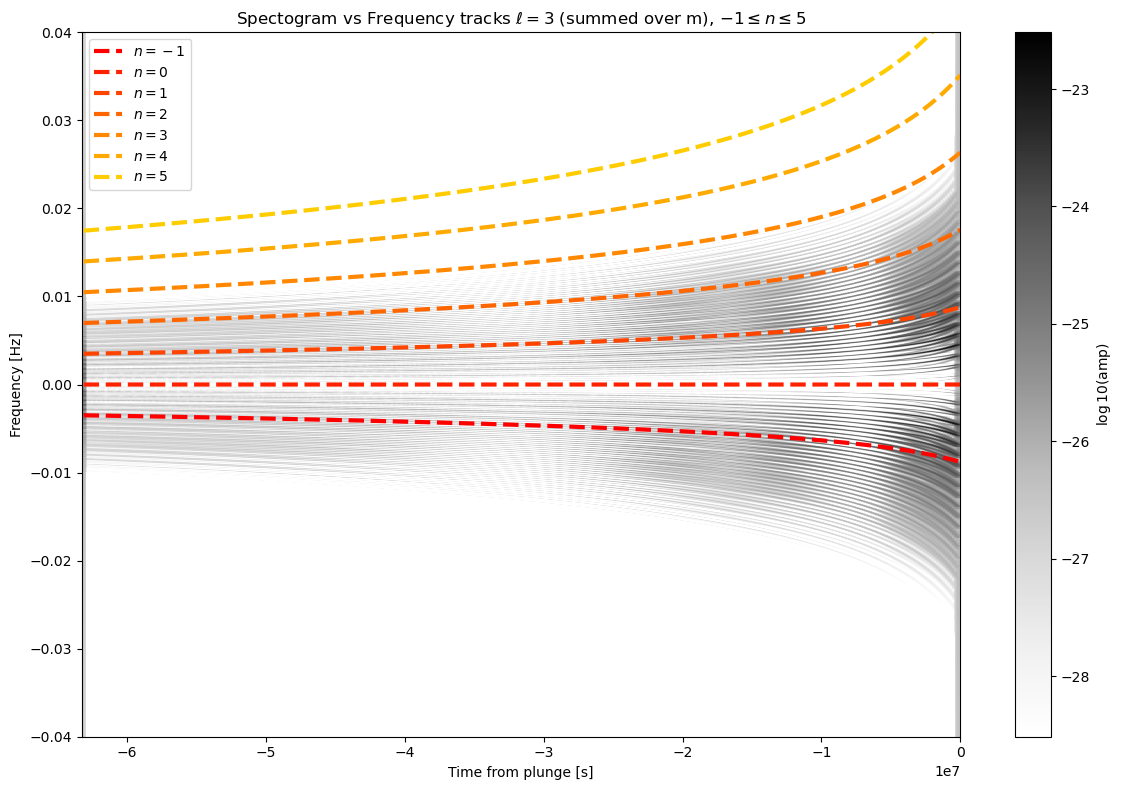

In [79]:

# Spectogram only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)



# plot summed freqs

n_values_summed = list(set(n for (ell, n) in summed_freqs.keys()))  
n_values_summed.sort()
cmap = cm.get_cmap('autumn') 
colors_summed = cmap(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 3:
        color_idx = n_values_summed.index(n)
        plt.plot(t_traj_years, freq, color=colors_summed[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
# for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
#     label = f'$(\ell={ell}, n={n})$'
#     if ell == 2:
#         plt.plot(t_traj_years, freq, color='red', linewidth=1, linestyle='dashed', alpha=1, label=label)


cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time from plunge [s]')
plt.title('Spectogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
# plt.ylim(None,0.04)
plt.ylim(-0.04, 0.04)

plt.legend()
plt.tight_layout()
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\l'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3840519218.py:29: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_title('Spectrogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3840519218.py:49: SyntaxWarning: invalid escape sequence '\e'
  ax3.set_title('Spectrogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3840519218.py:55: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3840519218.py:18: MatplotlibDeprecationWarning: The get_cmap function was

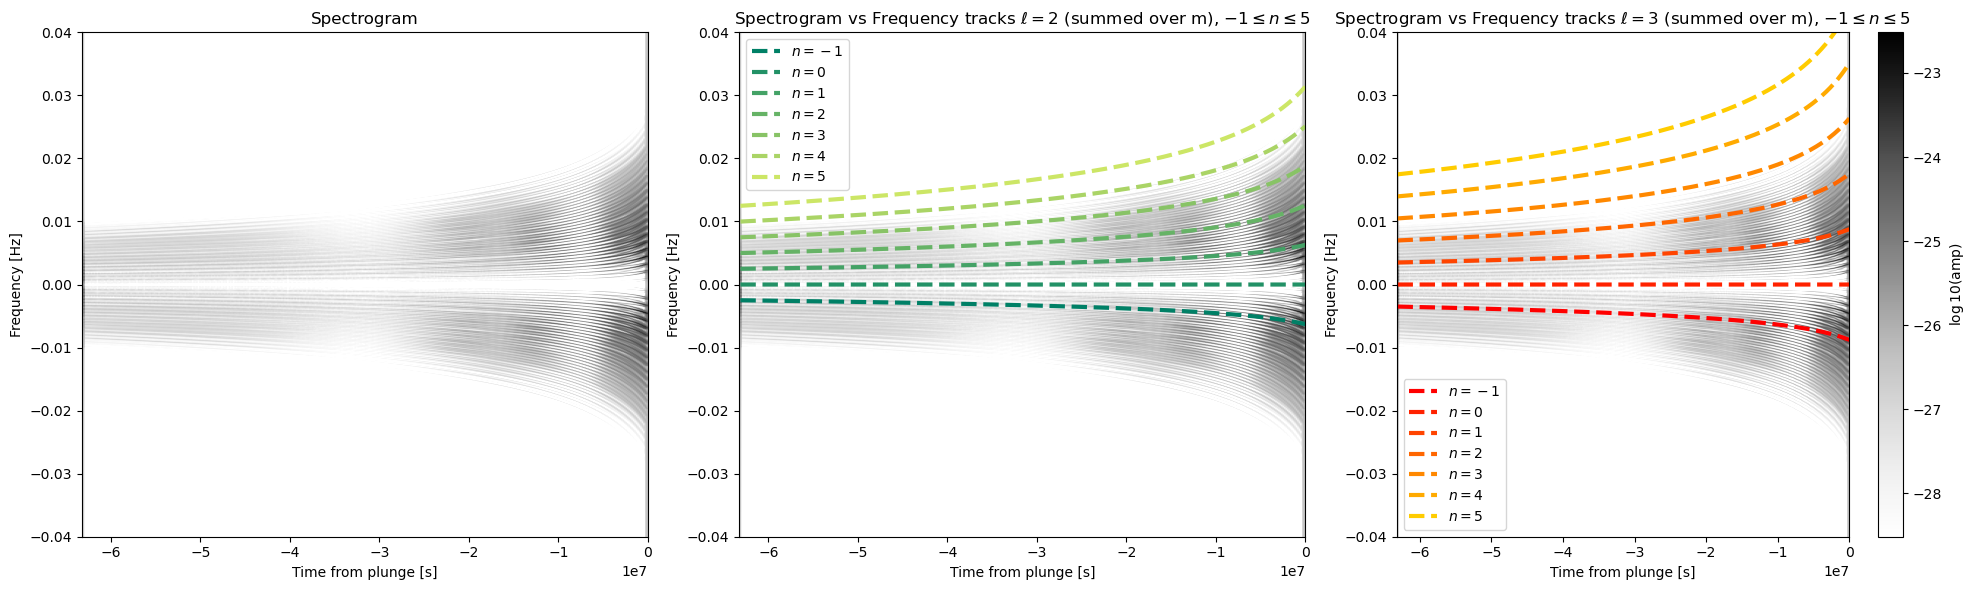

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Subplot 1: STFT amplitudes only
ax1 = axes[0]
im = ax1.imshow(log_amp, aspect='auto', origin='lower', extent=extent, 
                 cmap='Greys', vmin=vmin_val, vmax=max_val)
ax1.set_ylim(-0.04, 0.04)
ax1.set_xlabel('Time from plunge [s]')
ax1.set_ylabel('Frequency [Hz]')
ax1.set_title('Spectrogram')

# Subplot 2: ell=2 (summed over m)
ax2 = axes[1]
ax2.imshow(log_amp, aspect='auto', origin='lower', extent=extent, 
           cmap='Greys', vmin=vmin_val, vmax=max_val)

n_values_summed = list(set(n for (ell, n) in summed_freqs.keys()))  
n_values_summed.sort()
cmap_summer = cm.get_cmap('summer') 
colors_summer = cmap_summer(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 2:
        color_idx = n_values_summed.index(n)
        ax2.plot(t_traj_years, freq, color=colors_summer[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

ax2.set_ylabel('Frequency [Hz]')
ax2.set_xlabel('Time from plunge [s]')
ax2.set_title('Spectrogram vs Frequency tracks $\ell=2$ (summed over m), $-1 \leq n \leq 5$')
ax2.set_ylim(-0.04, 0.04)
ax2.legend()

# Subplot 3: ell=3 (summed over m)
ax3 = axes[2]
ax3.imshow(log_amp, aspect='auto', origin='lower', extent=extent, 
           cmap='Greys', vmin=vmin_val, vmax=max_val)

cmap_autumn = cm.get_cmap('autumn') 
colors_autumn = cmap_autumn(np.linspace(0, 0.8, len(n_values_summed)))

for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = f'$n={n}$'
    if ell == 3:
        color_idx = n_values_summed.index(n)
        ax3.plot(t_traj_years, freq, color=colors_autumn[color_idx], linewidth=3, linestyle='dashed', alpha=1, label=label)

ax3.set_ylabel('Frequency [Hz]')
ax3.set_xlabel('Time from plunge [s]')
ax3.set_title('Spectrogram vs Frequency tracks $\ell=3$ (summed over m), $-1 \leq n \leq 5$')
ax3.set_ylim(-0.04, 0.04)
ax3.legend()

# Single colorbar for all subplots
cbar = fig.colorbar(im, ax=ax3)å
cbar.set_label(f"$\log10$(amp)")

plt.tight_layout()
plt.show()

In [87]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

In [102]:
nperseg

65536

In [149]:
nperseg = 2**16  
noverlap = nperseg * 3 // 4  # 

# nperseg = 2**14
# noverlap = nperseg // 2
f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get().real, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get().real, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')



In [150]:
Zxx_l2

array([[ 3.82648879e-26+0.00000000e+00j,  1.91369596e-26+0.00000000e+00j,
        -2.13598869e-32+0.00000000e+00j, ...,
        -2.59618028e-27+0.00000000e+00j, -7.81134120e-27+0.00000000e+00j,
        -5.48161951e-27+0.00000000e+00j],
       [-3.82647108e-26+9.03732404e-30j, -4.57391195e-30-1.91369170e-26j,
        -2.14032536e-32-2.35371874e-33j, ...,
        -9.27385862e-28-2.42489761e-27j,  7.29600423e-27-2.79026367e-27j,
         1.95805138e-27+5.11998673e-27j],
       [ 3.82646273e-26-1.80676360e-29j, -1.91368095e-26+9.16675669e-30j,
        -2.15335765e-32-4.71283804e-33j, ...,
         1.93365029e-27-1.73240808e-27j, -5.81799070e-27+5.21238488e-27j,
         4.08280262e-27-3.65777012e-27j],
       ...,
       [-1.84772042e-27+1.59316227e-31j,  9.23820382e-28-7.96590044e-32j,
        -3.43985117e-39-8.97596808e-39j, ...,
        -9.50435533e-28-8.44811607e-28j,  2.85255833e-27+2.53554736e-27j,
        -1.99836610e-27-1.77628334e-27j],
       [ 1.84772042e-27-7.96581179e-32j, -3.

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3039218396.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
/var/tmp/pbs.521502.stdct-mgmt-02/ipykernel_2849698/3039218396.py:4: SyntaxWarning: invalid escape sequence '\e'
  labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\

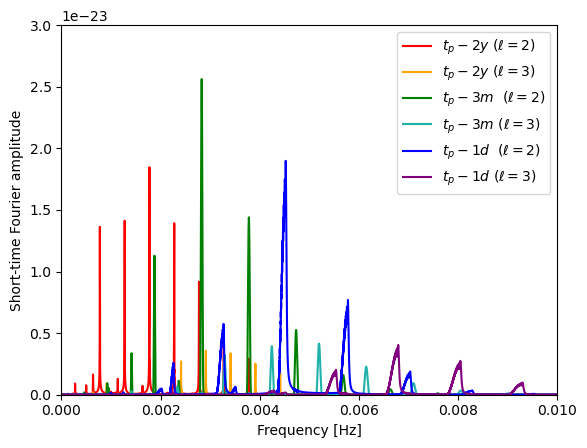

In [155]:
times_before_plunge = [2.0, 3/12, 1/365.25]  # 2y, 3m, 1d
colors_l2 = ['red', 'green', 'blue']
colors_l3 = ['orange', 'lightseagreen', 'purple']
labels_l2 = ['$t_p - 2y$ ($\ell=2$)', '$t_p - 3m$  ($\ell=2$)', '$t_p - 1d$  ($\ell=2$)']
labels_l3 = ['$t_p - 2y$ ($\ell=3$)', '$t_p - 3m$ ($\ell=3$)', '$t_p - 1d$ ($\ell=3$)']

fig, ax = plt.subplots()

for time_bp, color_l2, color_l3, label_l2, label_l3 in zip(times_before_plunge, colors_l2, colors_l3, labels_l2, labels_l3):
    target_time = -time_bp
    idx = np.argmin(np.abs(t_years_adjusted - target_time))
    # amplitude = np.sqrt(Sxx[:, idx])
    amplitude_l2 = np.abs(Zxx_l2[:, idx]) 
    amplitude_l3 = np.abs(Zxx_l3[:, idx])  

    ax.plot(f_l2, amplitude_l2, color=color_l2, label=label_l2, linewidth=1.5)
    ax.plot(f_l3, amplitude_l3, color=color_l3, label=label_l3, linewidth=1.5)


ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Short-time Fourier amplitude')
ax.set_xlim([0, 0.01])
ax.set_ylim([0, 3*10**(-23)]) 
ax.legend()

In [148]:
T,dt

(2.0, 10.0)

In [93]:
snr_full = gwf.rhostat(h)
snr_full

array(32.54153962)

In [94]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(28.86760808)

In [95]:
p_l2 = gwf.rhostat(h_l2)**2/gwf.rhostat(h)**2 * 100
p_l2

array(78.69468616)

In [96]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(13.6560397)

In [97]:
p_l3 = gwf.rhostat(h_l3)**2 /gwf.rhostat(h)**2 *100
p_l3

array(17.61056738)

In [98]:
p_l2+p_l3

array(96.30525354)